In [1]:
from torchvision import datasets
from torchvision.transforms import ToTensor

In [2]:
tensor_transformer = ToTensor()
full_train_data = datasets.MNIST(
    root="data", download=False, train=True, transform=tensor_transformer
)

test_data = datasets.MNIST(
    root="data", download=False, train=False, transform=tensor_transformer
)

In [3]:
print("Full training set: ", len(full_train_data), "\nTesting set: ", len(test_data))

Full training set:  60000 
Testing set:  10000


In [4]:
from torch.utils.data import random_split

In [5]:
train_size = 50000
val_size = 10000

train_data, val_data = random_split(full_train_data, [train_size, val_size])

print(
    "Train set: ",
    len(train_data),
    "\nVal set: ",
    len(val_data),
    "\nTest set: ",
    len(test_data),
)

Train set:  50000 
Val set:  10000 
Test set:  10000


In [6]:
from torch.utils.data import DataLoader

In [7]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [8]:
import torch.nn as nn

In [9]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.layers(x)

In [10]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 10
learning_rate = 0.001

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(epochs):
    model.train()
    t_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()

    model.eval()
    v_loss, correct = 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            v_loss += criterion(out, y).item()
            correct += (out.argmax(1) == y).sum().item()

    # Logowanie (English logs)
    history["train_loss"].append(t_loss / len(train_loader))
    history["val_loss"].append(v_loss / len(val_loader))
    history["val_acc"].append(correct / len(val_data))
    print(
        f"Epoch {epoch + 1}/{epochs} | Loss: {history['train_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.4f}"
    )

# 2. Ewaluacja i zbieranie danych do metryk
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        all_preds.extend(model(x).argmax(1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

Epoch 1/10 | Loss: 0.2437 | Val Acc: 0.9738
Epoch 2/10 | Loss: 0.0636 | Val Acc: 0.9800
Epoch 3/10 | Loss: 0.0422 | Val Acc: 0.9822
Epoch 4/10 | Loss: 0.0326 | Val Acc: 0.9865
Epoch 5/10 | Loss: 0.0254 | Val Acc: 0.9855
Epoch 6/10 | Loss: 0.0205 | Val Acc: 0.9868
Epoch 7/10 | Loss: 0.0157 | Val Acc: 0.9850
Epoch 8/10 | Loss: 0.0148 | Val Acc: 0.9879
Epoch 9/10 | Loss: 0.0105 | Val Acc: 0.9866
Epoch 10/10 | Loss: 0.0097 | Val Acc: 0.9856


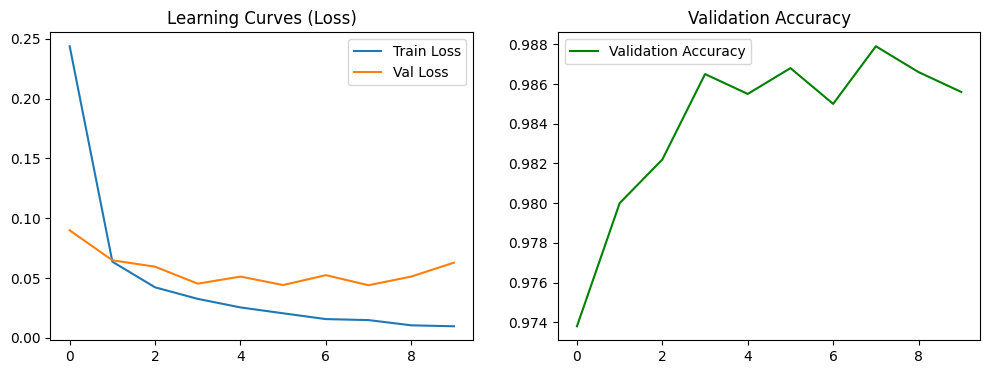

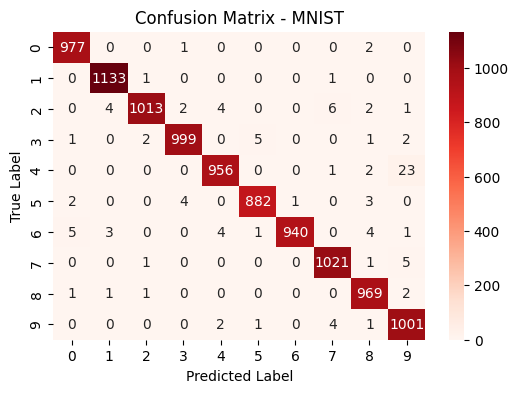


--- Full Classification Report ---
              precision    recall  f1-score   support

           0     0.9909    0.9969    0.9939       980
           1     0.9930    0.9982    0.9956      1135
           2     0.9951    0.9816    0.9883      1032
           3     0.9930    0.9891    0.9911      1010
           4     0.9896    0.9735    0.9815       982
           5     0.9921    0.9888    0.9905       892
           6     0.9989    0.9812    0.9900       958
           7     0.9884    0.9932    0.9908      1028
           8     0.9838    0.9949    0.9893       974
           9     0.9671    0.9921    0.9795      1009

    accuracy                         0.9891     10000
   macro avg     0.9892    0.9890    0.9890     10000
weighted avg     0.9892    0.9891    0.9891     10000



In [12]:
# 3. Wykresy (Learning Curves)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Learning Curves (Loss)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["val_acc"], label="Validation Accuracy", color="green")
plt.title("Validation Accuracy")
plt.legend()
plt.show()

# 4. Confusion Matrix (Macierz pomyłek)
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - MNIST")
plt.show()

# 5. Wszystkie metryki (Precision, Recall, F1-Score)
print("\n--- Full Classification Report ---")
print(classification_report(all_labels, all_preds, digits=4))